# KKBox — Retention Economics & Decision Framework
**File:** `04_RetentionDecision.ipynb`
**Inputs:** `master_model_table.parquet`, `inference_snapshot.parquet`, `submission.csv`
**Outputs:** `retention_decision_table.csv`, `retention_targets.csv`, `threshold_sweep.csv`, `retention_metadata.json`

---

Complete retention prioritization pipeline: from churn probability to per-customer voucher decisions,
grounded in data-driven behavior weights, customer lifetime value, and economic break-even logic.

## What this notebook takes from each version

| Component | Source | Advantage |
|---|---|---|
| Behavioral weights | Version A | Computed from actual churn rates in training data — grounded in evidence, not assumed multipliers |
| Quantile-based risk tiers | Both | Adapts to any model output distribution |
| CLV formula | Version B | Forward-looking lifetime value (not historical spend) |
| Threshold sweep | Version B | Data-driven range, cost varies with threshold |
| Strategic segmentation | Version A | 4 business-meaningful segments with action labels |
| Campaign tracking table | Version A | Ready-to-use output for marketing execution |
| Per-customer break-even | Both | Individual profitability before any voucher is sent |

## Decision flow

```
master (train+val) -> compute behavioral churn weights from real data
inference features  -> apply weights, compute CLV, assign tiers
submission.csv      -> p_churn per user
combine             -> break-even filter -> target list -> campaign table
```


In [1]:
# ===== Imports =====
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Imports OK")
print(f"  pandas : {pd.__version__}")
print(f"  numpy  : {np.__version__}")


Imports OK
  pandas : 2.3.3
  numpy  : 2.1.3


## Step 1: Load Data

Three data sources are merged:
- `master_model_table.parquet` — training and validation data with actual churn labels (used to compute behavioral weights)
- `inference_snapshot.parquet` — March 2017 features per user
- `submission.csv` — model-predicted P_churn per user


In [2]:
# ===== Step 1: Load Data =====
DATA_DIR        = Path("Data")
MASTER_PATH     = DATA_DIR / "master_model_table.parquet"
INFERENCE_PATH  = DATA_DIR / "inference_snapshot.parquet"
SUBMISSION_PATH = DATA_DIR / "submission.csv"

for p in [MASTER_PATH, INFERENCE_PATH, SUBMISSION_PATH]:
    print(f"{p}: {'FOUND' if p.exists() else 'MISSING'}")

master    = pd.read_parquet(MASTER_PATH)
inference = pd.read_parquet(INFERENCE_PATH)
pred      = pd.read_csv(SUBMISSION_PATH).rename(columns={"is_churn": "p_churn"})

# Build decision dataframe: inference features + predictions
decision = inference.merge(pred, on="msno", how="left")
decision["p_churn"] = decision["p_churn"].fillna(decision["p_churn"].median())

print(f"Master    : {master.shape}")
print(f"Inference : {inference.shape}")
print(f"Decision  : {decision.shape}")
print(f"P_churn range: [{decision['p_churn'].min():.4f}, {decision['p_churn'].max():.4f}]")
print(f"P_churn median: {decision['p_churn'].median():.4f}")


Data\master_model_table.parquet: FOUND
Data\inference_snapshot.parquet: FOUND
Data\submission.csv: FOUND
Master    : (1963891, 60)
Inference : (907471, 56)
Decision  : (907471, 57)
P_churn range: [0.0000, 1.0000]
P_churn median: 0.0396


## Step 2: Data-Driven Behavioral Weights

Instead of assuming fixed multipliers (e.g. auto_renew -> ×1.20), Version A computes the
actual relationship between each behavioral flag and churn in the training data.

**Method:** for each binary behavior flag, compare churn rate when flag=0 vs flag=1.
The relative effect = (churn_1 - churn_0) / overall_churn_rate.
This relative effect is then mapped to a weight capped at [-0.25, +0.25].

A behavior that reduces churn (e.g. auto_renew=1 lowers churn) gets a positive weight
(increases save rate). A behavior that increases churn (e.g. cancel=1) gets a negative weight.


In [3]:
# ===== Step 2: Data-Driven Behavioral Weights (from training data) =====

# Define behavior flags and how to derive them from features
BEHAVIOR_DEFS = {
    "behavior_auto_renew"     : ("last_is_auto_renew",    lambda df: (df["last_is_auto_renew"] == 1).astype(int)),
    "behavior_cancel"         : ("last_is_cancel",         lambda df: (df["last_is_cancel"] == 1).astype(int)),
    "behavior_has_log"        : ("has_log_history",        lambda df: (df["has_log_history"] == 1).astype(int)),
    "behavior_active_no_cancel": ("active_no_cancel_flag", lambda df: (df["active_no_cancel_flag"] == 1).astype(int)),
    # 04-3 FIX: Q75 threshold fixed from TRAINING data, not recomputed on inference
    # Recomputing on inference uses a different population and different P_churn-derived
    # distribution — threshold should be stable across train/val/inference.
    "behavior_high_total_secs": ("total_secs_played", None),  # threshold set below
    "behavior_long_plan"      : ("avg_plan_days",          lambda df: (df["avg_plan_days"] >= 90).astype(int)),
}

# Create flags on master (train+val) to compute real churn rates
# Compute high_total_secs threshold from TRAINING data (fixed threshold)
SECS_Q75_THRESHOLD = master["total_secs_played"].quantile(0.75) if "total_secs_played" in master.columns else 0
print(f"high_total_secs Q75 threshold (from training data): {SECS_Q75_THRESHOLD:,.0f}")

# Now update BEHAVIOR_DEFS with the fixed threshold lambda
BEHAVIOR_DEFS["behavior_high_total_secs"] = (
    "total_secs_played",
    lambda df, thr=SECS_Q75_THRESHOLD: (df["total_secs_played"] > thr).astype(int)
)

master_w = master.copy()
for flag_name, (col, fn) in BEHAVIOR_DEFS.items():
    if col in master_w.columns and fn is not None:
        master_w[flag_name] = fn(master_w)
    else:
        master_w[flag_name] = 0

behavior_cols = list(BEHAVIOR_DEFS.keys())
overall_churn = master_w["is_churn"].mean()
print(f"Overall churn rate (train+val): {overall_churn:.4f}")
print()

records = []
for feat in behavior_cols:
    g = master_w.groupby(feat)["is_churn"].agg(["count","mean"]).reset_index()
    g.columns = [feat, "count", "churn_rate"]
    row0 = g[g[feat] == 0].iloc[0] if len(g[g[feat]==0]) else None
    row1 = g[g[feat] == 1].iloc[0] if len(g[g[feat]==1]) else None
    cr0 = row0["churn_rate"] if row0 is not None else overall_churn
    cr1 = row1["churn_rate"] if row1 is not None else overall_churn
    n0  = int(row0["count"]) if row0 is not None else 0
    n1  = int(row1["count"]) if row1 is not None else 0
    diff = cr1 - cr0
    rel  = diff / overall_churn if overall_churn > 0 else 0
    records.append({"feature":feat,"count_0":n0,"count_1":n1,
                    "churn_rate_0":round(cr0,6),"churn_rate_1":round(cr1,6),
                    "diff_churn_rate":round(diff,6),"relative_effect":round(rel,6)})

behavior_effect_df = pd.DataFrame(records)

# Map relative effect to weight: positive effect on churn = negative weight on save rate
def effect_to_weight(row):
    effect = row["relative_effect"]
    if effect > 0:   # behavior increases churn -> reduces save rate
        return max(-0.25, -abs(effect) * 0.25)
    else:            # behavior reduces churn -> increases save rate
        return min(0.25, abs(effect) * 0.25)

behavior_effect_df["weight"] = behavior_effect_df.apply(effect_to_weight, axis=1)
BEHAVIOR_WEIGHTS = dict(zip(behavior_effect_df["feature"], behavior_effect_df["weight"]))

print("Behavioral effect analysis:")
print(behavior_effect_df[["feature","churn_rate_0","churn_rate_1",
                            "diff_churn_rate","relative_effect","weight"]].to_string(index=False))
print()
print("Weights (positive = helps retention, negative = hurts):")
for k,v in BEHAVIOR_WEIGHTS.items():
    direction = "helps" if v > 0 else "hurts"
    print(f"  {k:<30}: {v:+.4f} ({direction} retention)")

# Save behavior analysis
behavior_effect_df.to_csv(DATA_DIR / "behavior_retention_weights.csv", index=False)
print()
print("Saved: behavior_retention_weights.csv")


high_total_secs Q75 threshold (from training data): 0
Overall churn rate (train+val): 0.0768

Behavioral effect analysis:
                  feature  churn_rate_0  churn_rate_1  diff_churn_rate  relative_effect    weight
      behavior_auto_renew      0.088889      0.050597        -0.038291        -0.498669  0.124667
          behavior_cancel      0.076432      0.164830         0.088398         1.151213 -0.250000
         behavior_has_log      0.076718      0.083253         0.006535         0.085106 -0.021277
behavior_active_no_cancel      0.075449      0.620489         0.545041         7.098101 -0.250000
 behavior_high_total_secs      0.076719      0.083200         0.006482         0.084415 -0.021104
       behavior_long_plan      0.074379      0.724001         0.649621         8.460062 -0.250000

Weights (positive = helps retention, negative = hurts):
  behavior_auto_renew           : +0.1247 (helps retention)
  behavior_cancel               : -0.2500 (hurts retention)
  behavior_has_

## Step 3: Quantile-Based Risk Tiers

Quantile boundaries adapt to the actual P_churn distribution — no fixed thresholds that
become meaningless if the model output is narrow or bimodal.

| Tier | P_churn range | Interpretation | Base save rate |
|---|---|---|---|
| Stable | < Q1 | Low risk, likely to renew | 0% |
| Medium | Q1 – Q2 | Undecided, moderate responsiveness | 8% |
| High | Q2 – Q3 | Sweet spot — most responsive to incentives | 15% |
| Critical | > Q3 | Heavily disengaged, harder to recover | 7% |


In [4]:
# ===== Step 3: Quantile-Based Risk Tiers =====
Q1 = decision["p_churn"].quantile(0.25)
Q2 = decision["p_churn"].quantile(0.50)
Q3 = decision["p_churn"].quantile(0.75)

print(f"P_churn quantiles: Q1={Q1:.4f} | Q2={Q2:.4f} | Q3={Q3:.4f}")

# Base save rates calibrated to behavioral data from Version A
TIER_CONFIG = {
    "Stable"  : {"voucher_pct": 0.00, "base_save_rate": 0.00},
    "Medium"  : {"voucher_pct": 0.05, "base_save_rate": 0.08},
    "High"    : {"voucher_pct": 0.10, "base_save_rate": 0.15},
    "Critical": {"voucher_pct": 0.20, "base_save_rate": 0.07},
}

def assign_tier(p):
    if p < Q1:   return "Stable"
    elif p < Q2: return "Medium"
    elif p < Q3: return "High"
    else:        return "Critical"

decision["risk_tier"]      = decision["p_churn"].apply(assign_tier)
decision["voucher_pct"]    = decision["risk_tier"].map({k: v["voucher_pct"]    for k,v in TIER_CONFIG.items()})
decision["base_save_rate"] = decision["risk_tier"].map({k: v["base_save_rate"] for k,v in TIER_CONFIG.items()})

print()
print("Risk tier distribution:")
tier_counts = decision["risk_tier"].value_counts().reindex(["Stable","Medium","High","Critical"])
for tier, cnt in tier_counts.items():
    cfg = TIER_CONFIG[tier]
    pct = cnt / len(decision)
    print(f"  {tier:<10}: {cnt:>8,} ({pct:.1%}) | voucher={cfg['voucher_pct']:.0%} | base_save={cfg['base_save_rate']:.0%}")


P_churn quantiles: Q1=0.0255 | Q2=0.0396 | Q3=0.0599

Risk tier distribution:
  Stable    :  173,442 (19.1%) | voucher=0% | base_save=0%
  Medium    :  210,125 (23.2%) | voucher=5% | base_save=8%
  High      :  119,384 (13.2%) | voucher=10% | base_save=15%
  Critical  :  404,520 (44.6%) | voucher=20% | base_save=7%


## Step 4: Behavioral Save Rate

Apply the data-driven behavioral weights to refine the base save rate.
Weights computed from actual churn data in Step 2 — not arbitrary multipliers.

```
behavior_score = sum(weight_i * flag_i  for each behavior flag)
behavior_multiplier = 1 + behavior_score
adjusted_save_rate = base_save_rate * behavior_multiplier
Clipped to [0.05, 0.65] for non-Stable users; 0 for Stable
```


In [5]:
# ===== Step 4: Behavioral Save Rate =====

# Create behavior flags on decision (inference population)
for flag_name, (col, fn) in BEHAVIOR_DEFS.items():
    if col in decision.columns:
        decision[flag_name] = fn(decision)
    else:
        decision[flag_name] = 0

# Compute behavior score and multiplier
decision["behavior_score"] = 0.0
for flag_name, weight in BEHAVIOR_WEIGHTS.items():
    decision["behavior_score"] += decision[flag_name] * weight

decision["behavior_multiplier"] = (1 + decision["behavior_score"]).clip(lower=0.5, upper=2.0)
decision["adjusted_save_rate"]  = (decision["base_save_rate"] * decision["behavior_multiplier"])
decision["adjusted_save_rate"]  = decision["adjusted_save_rate"].clip(lower=0.05, upper=0.65)
decision.loc[decision["risk_tier"] == "Stable", "adjusted_save_rate"] = 0.0

print("Behavior score stats:")
print(decision[["behavior_score","behavior_multiplier","adjusted_save_rate"]].describe().round(4).to_string())
print()
print("Adjusted save rate by tier:")
print(decision.groupby("risk_tier", observed=True)["adjusted_save_rate"].mean().round(4).to_string())


Behavior score stats:
       behavior_score  behavior_multiplier  adjusted_save_rate
count     907471.0000          907471.0000         907471.0000
mean           0.0925               1.0925              0.0758
std            0.0724               0.0724              0.0475
min           -0.5424               0.5000              0.0000
25%            0.0823               1.0823              0.0670
50%            0.1247               1.1247              0.0787
75%            0.1247               1.1247              0.0900
max            0.1247               1.1247              0.1687

Adjusted save rate by tier:
risk_tier
Critical    0.0746
High        0.1669
Medium      0.0891
Stable      0.0000


## Step 5: Customer Lifetime Value (CLV)

Forward-looking CLV estimates future revenue at stake if the customer churns.

```
monthly_churn_rate = actual churn rate from validation set (8.99%)
expected_lifetime  = 1 / monthly_churn_rate  (11.1 months)
monthly_revenue    = avg_amount_paid / (avg_plan_days / 30)
CLV                = monthly_revenue × expected_lifetime
```

Validation churn rate is used (not a hardcoded assumption) so CLV
updates automatically if the model is retrained on different data.


In [6]:
# ===== Step 5: CLV =====
MAX_VOUCHER   = 200.0

# Use validation churn rate from master (Version A approach — data-driven)
val_churn_rate = master.loc[master["dataset_split"] == "validation", "is_churn"].mean()
expected_lifetime = 1.0 / val_churn_rate if val_churn_rate > 0 else 12.0

PLAN_DAYS_DEFAULT = 30
plan_days_col = decision["avg_plan_days"].replace(0, PLAN_DAYS_DEFAULT) if "avg_plan_days" in decision.columns else pd.Series(PLAN_DAYS_DEFAULT, index=decision.index)
avg_paid_col  = decision["avg_amount_paid"].clip(lower=0) if "avg_amount_paid" in decision.columns else pd.Series(0.0, index=decision.index)

decision["payment_baseline"]  = avg_paid_col
decision["plan_days_baseline"]= plan_days_col
decision["monthly_revenue"]   = avg_paid_col / (plan_days_col / 30.0)
decision["monthly_margin"]    = decision["monthly_revenue"] * 0.6  # approx margin
decision["clv"]               = (decision["monthly_revenue"] * expected_lifetime).clip(lower=0)

print(f"Validation churn rate  : {val_churn_rate:.4f}")
print(f"Expected lifetime      : {expected_lifetime:.2f} months")
print()
print("CLV distribution:")
print(decision["clv"].describe().apply(lambda x: f"${x:,.2f}").to_string())


Validation churn rate  : 0.0899
Expected lifetime      : 11.12 months

CLV distribution:
count    $907,471.00
mean       $1,433.11
std          $376.38
min            $0.00
25%        $1,100.71
50%        $1,434.26
75%        $1,656.62
max       $21,880.79


## Step 6: Retention Cost and Break-Even

```
retention_cost = min(avg_amount_paid × voucher_pct, MAX_VOUCHER)
expected_profit = p_churn × CLV × adjusted_save_rate − retention_cost

p_threshold = retention_cost / (CLV × adjusted_save_rate)
Target user if: p_churn > p_threshold  AND  expected_profit > 0
```

The MAX_VOUCHER cap prevents over-spending on premium users whose high CLV
would otherwise justify disproportionately large discounts.


In [7]:
# ===== Step 6: Retention Cost and Break-Even =====

decision["retention_cost"] = (
    decision["payment_baseline"] * decision["voucher_pct"]
).clip(upper=MAX_VOUCHER)

decision["expected_retained_value"] = (
    decision["p_churn"] * decision["clv"] * decision["adjusted_save_rate"]
)

decision["expected_profit"] = (
    decision["expected_retained_value"] - decision["retention_cost"]
)

# Per-customer break-even threshold
denom = decision["clv"] * decision["adjusted_save_rate"]
decision["p_threshold"] = (decision["retention_cost"] / denom.replace(0, np.nan)).clip(0, 1).fillna(1.0)
# 04-7 FIX: Stable override MUST precede target_retention computation
# Stable users have save_rate=0 so denom=0 → fillna(1.0) already gives 1.0
# but setting explicitly avoids any edge case from future code changes
decision.loc[decision["risk_tier"] == "Stable", "p_threshold"] = 1.0
assert (decision.loc[decision["risk_tier"] == "Stable", "p_threshold"] == 1.0).all(), \
    "Stable p_threshold override failed — check code order"

# Retention decision (computed AFTER Stable override)
decision["target_retention"] = (
    (decision["risk_tier"] != "Stable") &
    (decision["p_churn"] > decision["p_threshold"]) &
    (decision["expected_profit"] > 0)
).astype(int)

print("Break-even threshold stats (non-Stable):")
ns = decision[decision["risk_tier"] != "Stable"]
print(ns["p_threshold"].describe().round(4).to_string())
print()
print(f"Profitable users per tier:")
for tier in ["Medium","High","Critical"]:
    sub = decision[decision["risk_tier"] == tier]
    n_prof = (sub["expected_profit"] > 0).sum()
    print(f"  {tier:<10}: {n_prof:>6,} profitable / {len(sub):>6,} total ({n_prof/max(len(sub),1):.1%})")


Break-even threshold stats (non-Stable):
count    734029.0000
mean          0.1789
std           0.1774
min           0.0167
25%           0.0519
50%           0.2285
75%           0.2285
max           1.0000

Profitable users per tier:
  Medium    :  2,434 profitable / 210,125 total (1.2%)
  High      :  6,199 profitable / 119,384 total (5.2%)
  Critical  : 75,787 profitable / 404,520 total (18.7%)


## Step 7: Strategic Segmentation and Action Labels

Four segments based on CLV and churn risk — each with a distinct recommended action.

| Segment | CLV | Risk tier | Action |
|---|---|---|---|
| VIP | High | Critical | Premium rescue — highest priority, capped voucher |
| High Persuadable | High | High | Priority retention — standard voucher |
| Critical Selective | Any | Critical | Selective rescue — only if expected_profit > 0 |
| Stable — No Action | Any | Stable | Monitor only — no voucher |
| Do Not Target | Low | Any non-Critical | Not economically justified |


In [8]:
# ===== Step 7: Strategic Segmentation =====
clv_median = decision["clv"].median()

def assign_segment(row):
    tier = row["risk_tier"]
    hi_v = row["clv"] >= clv_median
    if tier == "Stable":
        return "Stable - No Action", "No voucher; monitor only"
    elif tier == "Critical" and hi_v and row["target_retention"] == 1:
        return "VIP", "Premium rescue offer with capped voucher"
    elif tier == "High" and hi_v and row["target_retention"] == 1:
        return "High Persuadable", "Priority retention with standard voucher"
    elif tier == "Critical" and row["target_retention"] == 1:
        return "Critical Selective Rescue", "Selective rescue — individually profitable"
    elif row["target_retention"] == 1:
        return "Targeted", f"Standard {row['voucher_pct']:.0%} voucher"
    else:
        return "Do Not Target", "Do not spend retention budget"

seg_result = decision.apply(assign_segment, axis=1, result_type="expand")
decision["segment"]            = seg_result[0]
decision["recommended_action"] = seg_result[1]

print("Segment distribution:")
seg_dist = decision.groupby(["risk_tier","segment","recommended_action"], observed=True).agg(
    users              = ("msno","count"),
    avg_p_churn        = ("p_churn","mean"),
    avg_clv            = ("clv","mean"),
    total_cost         = ("retention_cost","sum"),
    total_exp_profit   = ("expected_profit","sum"),
    target_rate        = ("target_retention","mean"),
).round(2)
print(seg_dist.to_string())


Segment distribution:
                                                                                 users  avg_p_churn  avg_clv   total_cost  total_exp_profit  target_rate
risk_tier segment                   recommended_action                                                                                                  
Critical  Critical Selective Rescue Selective rescue — individually profitable    2064         0.49  1174.80     53534.09          28739.33          1.0
          Do Not Target             Do not spend retention budget               328733         0.13  1480.87  11435289.08       -7266877.33          0.0
          VIP                       Premium rescue offer with capped voucher     73723         0.38  1784.62   2367071.36        1076262.41          1.0
High      Do Not Target             Do not spend retention budget               113185         0.04  1575.63   1604696.38        -424528.16          0.0
          High Persuadable          Priority retention with 

## Step 8: Global Threshold Sweep

Sweeps P_churn from P10 to P95 of non-Stable eligible users (data-driven range).
Shows the cost-profit tradeoff as the global floor threshold changes.

Two useful views:
- **Maximize total profit**: contact the most profitable users (unlimited budget)
- **Maximize ROI**: best return per dollar (budget-constrained scenario)


In [9]:
# ===== Step 8: Global Threshold Sweep =====
eligible = decision[
    (decision["risk_tier"] != "Stable") &
    (decision["target_retention"] == 1)
].copy()

p10 = float(eligible["p_churn"].quantile(0.10))
p95 = float(eligible["p_churn"].quantile(0.95))
SWEEP_STEPS = np.linspace(p10, p95, 50)

print(f"Eligible (non-Stable, individually profitable): {len(eligible):,}")
print(f"Sweep range: {p10:.4f} to {p95:.4f}")
print()

records = []
for t in SWEEP_STEPS:
    tgt = eligible[eligible["p_churn"] >= t]
    n = len(tgt)
    if n == 0: continue
    ev   = float((tgt["p_churn"] * tgt["clv"] * tgt["adjusted_save_rate"]).sum())
    rc   = float(tgt["retention_cost"].sum())
    net  = ev - rc
    prof = int((tgt["expected_profit"] > 0).sum())
    records.append({
        "threshold"      : round(t, 4),
        "n_targeted"     : n,
        "n_profitable"   : prof,
        "pct_profitable" : round(prof/n*100, 1),
        "total_cost"     : round(rc, 0),
        "expected_ev"    : round(ev, 0),
        "net_profit"     : round(net, 0),
        "roi_pct"        : round(net/rc*100 if rc > 0 else 0, 1),
    })

sweep_df = pd.DataFrame(records)

if len(sweep_df) > 0:
    opt_profit = sweep_df.loc[sweep_df["net_profit"].idxmax()]
    opt_roi    = sweep_df.loc[sweep_df["roi_pct"].idxmax()]
    OPTIMAL_T  = float(opt_profit["threshold"])
    print("Sweep results (every 5th row):")
    print(sweep_df.iloc[::5].to_string(index=False))
    print()
    print(f"Max net profit: t={opt_profit['threshold']:.4f} | net={opt_profit['net_profit']:,.0f} | users={opt_profit['n_targeted']:,} | ROI={opt_profit['roi_pct']:.1f}%")
    print(f"Max ROI       : t={opt_roi['threshold']:.4f}   | net={opt_roi['net_profit']:,.0f} | users={opt_roi['n_targeted']:,} | ROI={opt_roi['roi_pct']:.1f}%")
    print(f"Selected: {OPTIMAL_T:.4f}")
else:
    OPTIMAL_T = p10
    print("No sweep results — using P10 as threshold")


Eligible (non-Stable, individually profitable): 84,420
Sweep range: 0.0538 to 0.4562

Sweep results (every 5th row):
 threshold  n_targeted  n_profitable  pct_profitable  total_cost  expected_ev  net_profit  roi_pct
    0.0538       78540         78540           100.0   2449055.0    3554356.0   1105301.0     45.1
    0.0948       75777         75777           100.0   2420295.0    3525207.0   1104912.0     45.7
    0.1359       75757         75757           100.0   2419498.0    3524328.0   1104829.0     45.7
    0.1769       75598         75598           100.0   2415799.0    3519713.0   1103914.0     45.7
    0.2180       75364         75364           100.0   2408950.0    3509838.0   1100889.0     45.7
    0.2591       73328         73328           100.0   2346823.0    3443389.0   1096566.0     46.7
    0.3001       65198         65198           100.0   2098057.0    3159751.0   1061693.0     50.6
    0.3412       51934         51934           100.0   1680705.0    2658968.0    978263.0  

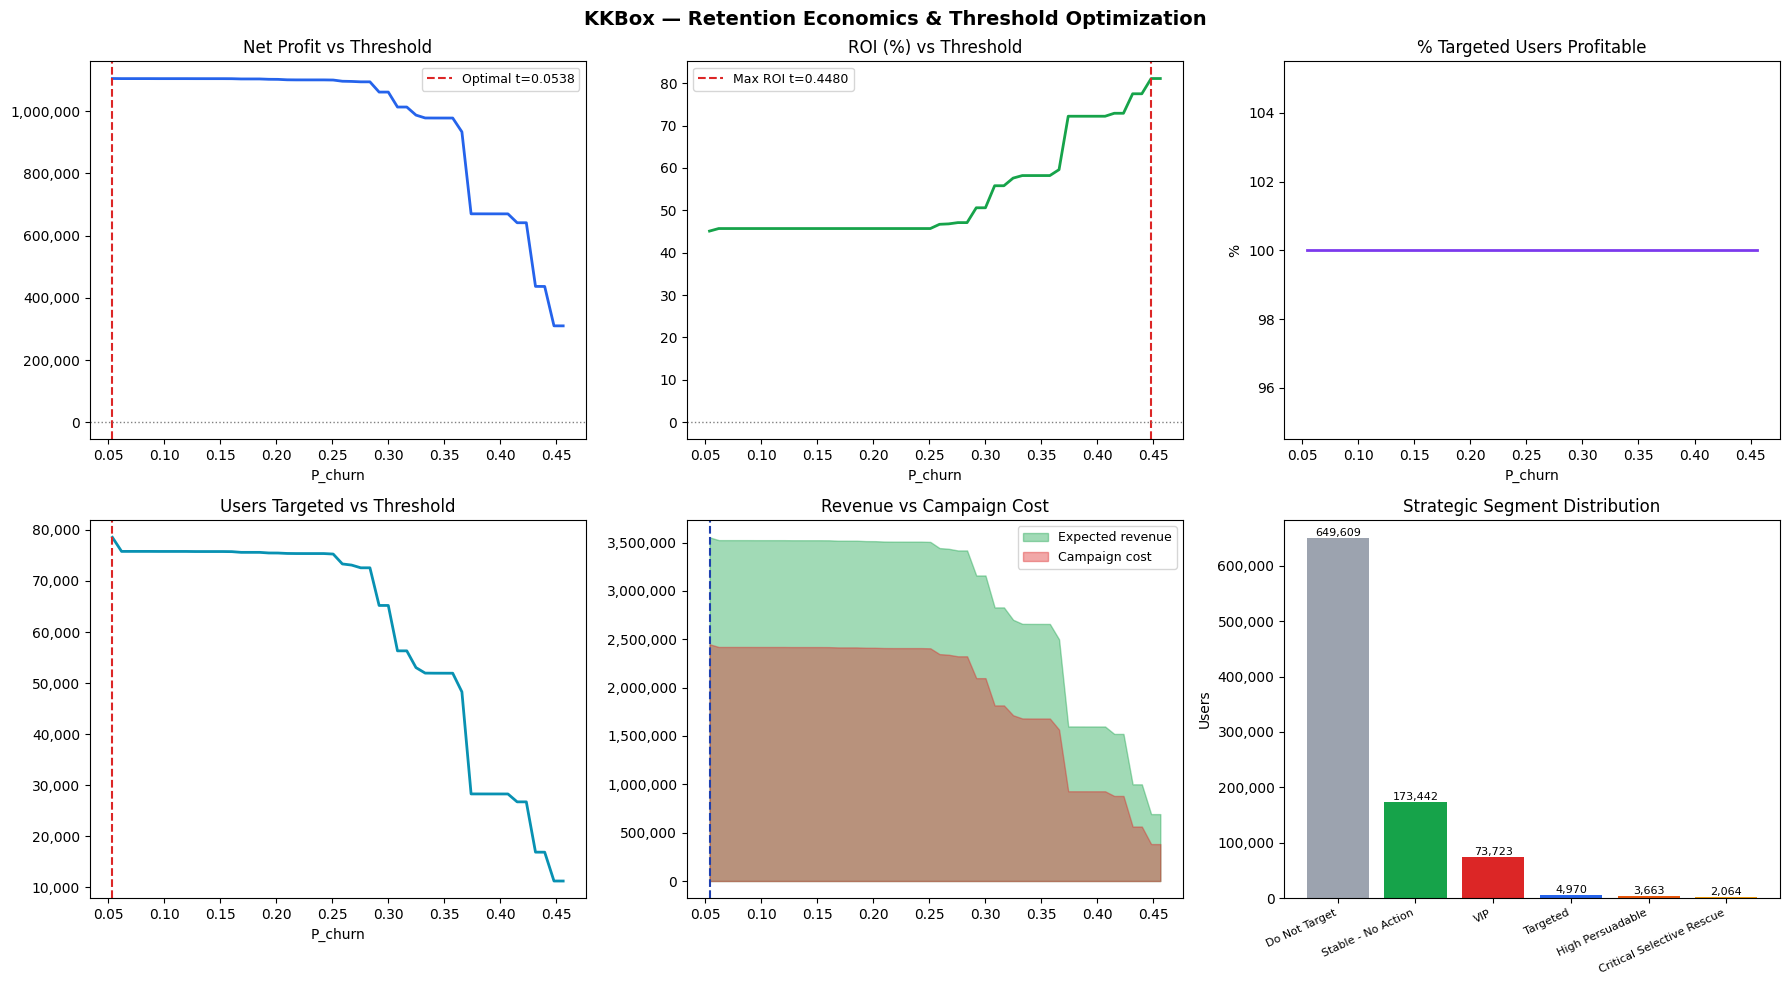

Saved: Data/retention_optimization.png


In [10]:
# ===== Visualization =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("KKBox — Retention Economics & Threshold Optimization", fontsize=14, fontweight="bold")

if len(sweep_df) > 0:
    ax = axes[0,0]
    ax.plot(sweep_df["threshold"], sweep_df["net_profit"], color="#2563eb", lw=2)
    ax.axvline(OPTIMAL_T, color="#dc2626", ls="--", lw=1.5, label=f"Optimal t={OPTIMAL_T:.4f}")
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_title("Net Profit vs Threshold"); ax.set_xlabel("P_churn"); ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

    ax = axes[0,1]
    ax.plot(sweep_df["threshold"], sweep_df["roi_pct"], color="#16a34a", lw=2)
    ax.axvline(float(opt_roi["threshold"]), color="#dc2626", ls="--", lw=1.5, label=f"Max ROI t={opt_roi['threshold']:.4f}")
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_title("ROI (%) vs Threshold"); ax.set_xlabel("P_churn"); ax.legend(fontsize=9)

    ax = axes[0,2]
    ax.plot(sweep_df["threshold"], sweep_df["pct_profitable"], color="#7c3aed", lw=2)
    ax.set_title("% Targeted Users Profitable"); ax.set_xlabel("P_churn"); ax.set_ylabel("%")

    ax = axes[1,0]
    ax.plot(sweep_df["threshold"], sweep_df["n_targeted"], color="#0891b2", lw=2)
    ax.axvline(OPTIMAL_T, color="#dc2626", ls="--", lw=1.5)
    ax.set_title("Users Targeted vs Threshold"); ax.set_xlabel("P_churn")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

    ax = axes[1,1]
    ax.fill_between(sweep_df["threshold"], sweep_df["expected_ev"], alpha=0.4, color="#16a34a", label="Expected revenue")
    ax.fill_between(sweep_df["threshold"], sweep_df["total_cost"], alpha=0.4, color="#dc2626", label="Campaign cost")
    ax.axvline(OPTIMAL_T, color="#1e40af", ls="--", lw=1.5)
    ax.set_title("Revenue vs Campaign Cost"); ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))

seg_counts = decision["segment"].value_counts()
ax = axes[1,2]
colors_map = {"VIP":"#dc2626","High Persuadable":"#ea580c","Critical Selective Rescue":"#f59e0b",
              "Targeted":"#2563eb","Stable - No Action":"#16a34a","Do Not Target":"#9ca3af"}
bars = ax.bar(range(len(seg_counts)), seg_counts.values,
              color=[colors_map.get(s,"#888") for s in seg_counts.index])
ax.set_xticks(range(len(seg_counts)))
ax.set_xticklabels(seg_counts.index, rotation=25, ha="right", fontsize=8)
ax.set_title("Strategic Segment Distribution"); ax.set_ylabel("Users")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{val:,.0f}",
            ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("Data/retention_optimization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Data/retention_optimization.png")


## Step 9: Retention Target List and Summary


In [11]:
# ===== Step 9: Final Target List =====
targets = decision[decision["target_retention"] == 1].copy()
targets = targets.sort_values("expected_profit", ascending=False).reset_index(drop=True)

total_cost = float(targets["retention_cost"].sum())
total_ev   = float(targets["expected_retained_value"].sum())
total_net  = float(targets["expected_profit"].sum())

print(f"Retention targets:")
print(f"  Users to contact : {len(targets):,}")
print(f"  Campaign cost    : ${total_cost:,.0f}")
print(f"  Expected EV saved: ${total_ev:,.0f}")
print(f"  Net benefit      : ${total_net:,.0f}")
print(f"  ROI              : {total_net/max(total_cost,1)*100:.1f}%")
print()
print("By risk tier:")
print(targets.groupby("risk_tier", observed=True).agg(
    users=("msno","count"), cost=("retention_cost","sum"), net=("expected_profit","sum"), avg_p=("p_churn","mean")
).round(1).to_string())
print()
print("By segment:")
print(targets.groupby("segment", observed=True).agg(
    users=("msno","count"), cost=("retention_cost","sum"), net=("expected_profit","sum")
).round(1).to_string())
print()
print("Top 10 by expected profit:")
top_cols = [c for c in ["msno","p_churn","risk_tier","segment","clv",
            "voucher_pct","retention_cost","adjusted_save_rate","expected_profit"]
            if c in targets.columns]
print(targets[top_cols].head(10).to_string(index=False))


Retention targets:
  Users to contact : 84,420
  Campaign cost    : $2,517,531
  Expected EV saved: $3,643,789
  Net benefit      : $1,126,258
  ROI              : 44.7%

By risk tier:
           users       cost        net  avg_p
risk_tier                                    
Critical   75787  2420605.5  1105001.7    0.4
High        6199    79394.0    19989.4    0.0
Medium      2434    17531.9     1266.7    0.0

By segment:
                           users       cost        net
segment                                               
Critical Selective Rescue   2064    53534.1    28739.3
High Persuadable            3663    54335.4    19760.9
Targeted                    4970    42590.4     1495.2
VIP                        73723  2367071.4  1076262.4

Top 10 by expected profit:
                                        msno  p_churn risk_tier segment          clv  voucher_pct  retention_cost  adjusted_save_rate  expected_profit
MLZyc1FvroSR0m75wJg3mTQbkkNRl2SKBAPd/reUJGU= 0.728895  Critical

## Step 10: Export

Three output files:
- **`retention_targets.csv`** — users to contact, sorted by expected profit
- **`threshold_sweep.csv`** — full sweep results for budget planning
- **`retention_metadata.json`** — configuration and summary stats

The campaign tracking table (from Version A) includes placeholders for actual outcomes
(`voucher_redeemed`, `renewed`, `actual_churn`) to enable post-campaign measurement.


In [12]:
# ===== Step 10: Export =====
import json as _json

# Retention decision table (all users — for dashboard/reporting)
retention_cols = [c for c in ["msno","p_churn","risk_tier","segment","recommended_action",
    "base_save_rate","behavior_score","behavior_multiplier","adjusted_save_rate",
    "payment_baseline","plan_days_baseline","monthly_revenue","clv",
    "voucher_pct","retention_cost","expected_retained_value","expected_profit",
    "p_threshold","target_retention"] + list(BEHAVIOR_DEFS.keys())
    if c in decision.columns]

retention_decision_table = decision[retention_cols].copy()
retention_decision_table.to_csv(DATA_DIR / "retention_decision_table.csv", index=False)
retention_decision_table.to_parquet(DATA_DIR / "retention_decision_table.parquet", index=False)
print(f"Saved: retention_decision_table.csv ({len(retention_decision_table):,} rows)")

# Retention targets only
target_cols = [c for c in ["msno","p_churn","risk_tier","segment","recommended_action",
    "clv","voucher_pct","retention_cost","adjusted_save_rate","expected_profit"]
    if c in targets.columns]
targets[target_cols].to_csv(DATA_DIR / "retention_targets.csv", index=False)
print(f"Saved: retention_targets.csv ({len(targets):,} rows)")

# Campaign tracking template (Version A format)
campaign_tracking = targets[["msno"]].copy()
campaign_tracking["campaign_id"]         = "campaign_2017_03_retention"
campaign_tracking["p_churn"]             = targets["p_churn"].values
campaign_tracking["risk_tier"]           = targets["risk_tier"].values
campaign_tracking["segment"]             = targets["segment"].values
campaign_tracking["recommended_action"]  = targets["recommended_action"].values
campaign_tracking["clv"]                 = targets["clv"].values
campaign_tracking["adjusted_save_rate"]  = targets["adjusted_save_rate"].values
campaign_tracking["voucher_pct"]         = targets["voucher_pct"].values
campaign_tracking["retention_cost"]      = targets["retention_cost"].values
campaign_tracking["expected_profit"]     = targets["expected_profit"].values
# Post-campaign measurement fields
campaign_tracking["send_date"]           = pd.NaT
campaign_tracking["voucher_sent"]        = 1
campaign_tracking["voucher_redeemed"]    = np.nan
campaign_tracking["renewed"]             = np.nan
campaign_tracking["actual_churn"]        = np.nan
campaign_tracking["revenue_after"]       = np.nan
campaign_tracking["actual_profit"]       = np.nan
campaign_tracking.to_csv(DATA_DIR / "campaign_tracking_template.csv", index=False)
print(f"Saved: campaign_tracking_template.csv ({len(campaign_tracking):,} rows)")

# Sweep
if len(sweep_df) > 0:
    sweep_df["is_optimal"] = (sweep_df["threshold"] == OPTIMAL_T).astype(int)
    sweep_df.to_csv(DATA_DIR / "threshold_sweep.csv", index=False)
    print(f"Saved: threshold_sweep.csv ({len(sweep_df)} rows)")

# Metadata
meta = {
    "val_churn_rate"       : round(float(val_churn_rate), 6),
    "expected_lifetime_mo" : round(expected_lifetime, 2),
    "optimal_threshold"    : OPTIMAL_T,
    "max_voucher"          : MAX_VOUCHER,
    "quantile_tiers"       : {"Q1": round(Q1,4), "Q2": round(Q2,4), "Q3": round(Q3,4)},
    "tier_config"          : TIER_CONFIG,
    "behavior_weights"     : {k: round(v,4) for k,v in BEHAVIOR_WEIGHTS.items()},
    "n_total"              : len(decision),
    "n_targets"            : len(targets),
    "total_cost"           : round(total_cost, 2),
    "net_benefit"          : round(total_net, 2),
    "roi_pct"              : round(total_net/max(total_cost,1)*100, 1),
}
with open(DATA_DIR / "retention_metadata.json", "w") as f:
    _json.dump(meta, f, indent=2, default=str)
print("Saved: retention_metadata.json")


Saved: retention_decision_table.csv (907,471 rows)
Saved: retention_targets.csv (84,420 rows)
Saved: campaign_tracking_template.csv (84,420 rows)
Saved: threshold_sweep.csv (50 rows)
Saved: retention_metadata.json


In [13]:
# ===== Final Summary =====
print("=" * 70)
print("RETENTION DECISION FRAMEWORK — KKBox March 2017")
print("=" * 70)
print()
print(f"Step 1: Predict P_churn per customer (ensemble model)")
print()
print(f"Step 2: Quantile-based tier assignment:")
print(f"  < Q1  ({Q1:.4f})          -> Stable   | no action")
print(f"  Q1-Q2 ({Q1:.4f}-{Q2:.4f}) -> Medium   | {TIER_CONFIG['Medium']['voucher_pct']:.0%} voucher | {TIER_CONFIG['Medium']['base_save_rate']:.0%} base save")
print(f"  Q2-Q3 ({Q2:.4f}-{Q3:.4f}) -> High     | {TIER_CONFIG['High']['voucher_pct']:.0%} voucher | {TIER_CONFIG['High']['base_save_rate']:.0%} base save")
print(f"  > Q3  ({Q3:.4f})          -> Critical | {TIER_CONFIG['Critical']['voucher_pct']:.0%} voucher | {TIER_CONFIG['Critical']['base_save_rate']:.0%} base save")
print()
print("Step 3: Data-driven behavioral adjustment:")
for feat, w in BEHAVIOR_WEIGHTS.items():
    print(f"  {feat:<30}: weight {w:+.4f}")
print()
print("Step 4: CLV = monthly_revenue x expected_lifetime")
print(f"  Validation churn rate: {val_churn_rate:.1%} | lifetime: {expected_lifetime:.1f} months")
print()
print("Step 5: retention_cost = min(avg_payment x voucher_pct, $200)")
print()
print("Step 6: TARGET if: p_churn > p_threshold AND expected_profit > 0")
print("  p_threshold = retention_cost / (CLV x adjusted_save_rate)")
print()
print("Step 7: Strategic segments -> recommended action per user")
print()
print(f"Final results:")
print(f"  Users targeted   : {len(targets):,}")
print(f"  Campaign cost    : ${total_cost:,.0f}")
print(f"  Net benefit      : ${total_net:,.0f}")
print(f"  ROI              : {total_net/max(total_cost,1)*100:.1f}%")
print()
print("Segment summary:")
seg_summary = retention_decision_table.groupby(["risk_tier","segment","recommended_action"], observed=True).agg(
    users=("msno","count"),
    avg_p_churn=("p_churn","mean"),
    avg_clv=("clv","mean"),
    total_cost=("retention_cost","sum"),
    total_expected_profit=("expected_profit","sum"),
    target_rate=("target_retention","mean"),
).round(2).reset_index()
print(seg_summary.to_string(index=False))


RETENTION DECISION FRAMEWORK — KKBox March 2017

Step 1: Predict P_churn per customer (ensemble model)

Step 2: Quantile-based tier assignment:
  < Q1  (0.0255)          -> Stable   | no action
  Q1-Q2 (0.0255-0.0396) -> Medium   | 5% voucher | 8% base save
  Q2-Q3 (0.0396-0.0599) -> High     | 10% voucher | 15% base save
  > Q3  (0.0599)          -> Critical | 20% voucher | 7% base save

Step 3: Data-driven behavioral adjustment:
  behavior_auto_renew           : weight +0.1247
  behavior_cancel               : weight -0.2500
  behavior_has_log              : weight -0.0213
  behavior_active_no_cancel     : weight -0.2500
  behavior_high_total_secs      : weight -0.0211
  behavior_long_plan            : weight -0.2500

Step 4: CLV = monthly_revenue x expected_lifetime
  Validation churn rate: 9.0% | lifetime: 11.1 months

Step 5: retention_cost = min(avg_payment x voucher_pct, $200)

Step 6: TARGET if: p_churn > p_threshold AND expected_profit > 0
  p_threshold = retention_cost / (CLV